
# Practical 23: **Multi-Class Image Segmentation (U-Net + Softmax)**

> **From Practical 22 ➜ Practical 23**  
> In **P22** you built a binary U-Net (1 channel + sigmoid + BCE). In **P23** you’ll scale to **multi-class** segmentation using **CamVid** (11 semantic classes) with **softmax** + **CrossEntropyLoss**. We will compute **per-class IoU**, **mIoU**, and **pixel accuracy**, and visualize predictions with a CamVid color palette.

### Learning Objectives
- Compare **binary vs. multi-class** segmentation heads and losses.  
- Convert **color masks → class indices** and handle **ignore labels** correctly.  
- Train a **U-Net** that outputs `C` channels (one per class).  
- Implement **IoU / mIoU / pixel accuracy** from a confusion matrix.  
- Present clear **visualizations** (GT vs. Pred) for classroom discussion.

### What changes from P22?
- Head: **1 channel + sigmoid** → **11 channels + softmax (implicit inside CrossEntropyLoss)**  
- Loss: **BCEWithLogitsLoss** → **CrossEntropyLoss(ignore_index=11)**  
- Metrics: **Binary IoU** → **per-class IoU + mIoU**



## 0) Setup

- CamVid directory layout:

```
CamVid/
  train/          train_labels/
  val/            val_labels/
  test/           test_labels/
```
> **Download Link:** [CamVid)](https://www.kaggle.com/datasets/carlolepelaars/camvid)


In [ ]:

# --- Imports & Reproducibility ---
import os, time, random, math, itertools, glob, shutil
from pathlib import Path
import numpy as np
from PIL import Image

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE


'cuda'

In [ ]:

# --- Data paths ---
DATA_DIR = Path("./data"); DATA_DIR.mkdir(parents=True, exist_ok=True)
CAMVID_ROOT = DATA_DIR / "CamVid"   # Put your CamVid/ folder here

print("CAMVID_ROOT:", CAMVID_ROOT.resolve())
print("Found train images:", len(list((CAMVID_ROOT/'train').glob('*.png'))) + len(list((CAMVID_ROOT/'train').glob('*.jpg'))))
print("Found train labels:", len(list((CAMVID_ROOT/'train_labels').glob('*.png'))))


CAMVID_ROOT: D:\CV\notebooks\data\CamVid
Found train images: 369
Found train labels: 369



## 1) Dataset: CamVid (11 classes)

**Classes (0–10):** Sky, Building, Pole, Road, Pavement, Tree, SignSymbol, Fence, Car, Pedestrian, Bicyclist.  
We reserve **11** as **IGNORE_INDEX** for unlabeled/void pixels (these should **not** affect the loss or metrics).

**Key idea:** CamVid masks are **color images** (each RGB color = a class). We need to convert **color → index** for training.


In [ ]:

# --- CamVid taxonomy & palette ---
CAMVID_CLASSES = ["Sky","Building","Pole","Road","Pavement","Tree","SignSymbol","Fence","Car","Pedestrian","Bicyclist"]
NUM_CLASSES = 11
IGNORE_INDEX = 11  # for unlabeled/void

# Common RGB codes used in CamVid splits (can differ slightly across sources—adjust if needed).
COLOR_TO_ID = {
    (128,128,128): 0,   # Sky
    (128,0,0):     1,   # Building
    (192,192,128): 2,   # Pole
    (128,64,128):  3,   # Road
    (60,40,222):   4,   # Pavement
    (128,128,0):   5,   # Tree
    (192,128,128): 6,   # SignSymbol
    (64,64,128):   7,   # Fence
    (64,0,128):    8,   # Car
    (64,64,0):     9,   # Pedestrian
    (0,128,192):   10,  # Bicyclist
    # anything else → ignore
}

# Build a 256-color palette for visualization (P-mode images in PIL)
PALETTE = []
for i in range(256):
    # find an RGB color for class 'i' (use black if none / ignore)
    rgb = next((c for c, cid in COLOR_TO_ID.items() if cid == i), (0,0,0))
    PALETTE += list(rgb)
# pad palette to length 256*3
PALETTE += [0] * (256*3 - len(PALETTE))



### 1.1 Color mask → class indices

**Why?** `CrossEntropyLoss` expects integer class IDs per pixel. We map each RGB color to its class index (0–10) and mark all other colors as **IGNORE_INDEX (11)**.


In [ ]:

def color_mask_to_index(mask_img: Image.Image) -> np.ndarray:
    # Convert a color-coded mask to HxW integer ids (0..10), others -> IGNORE_INDEX.
    m = np.array(mask_img.convert("RGB"))
    H, W, _ = m.shape
    out = np.full((H, W), IGNORE_INDEX, dtype=np.int64)
    for (r,g,b), cid in COLOR_TO_ID.items():
        match = (m[:,:,0]==r) & (m[:,:,1]==g) & (m[:,:,2]==b)
        out[match] = cid
    return out

def colorize_index_mask(idx_mask: np.ndarray) -> Image.Image:
    # Visualize an index mask with the CamVid palette (P-mode).
    img = Image.fromarray(idx_mask.astype(np.uint8), mode="P")
    img.putpalette(PALETTE)
    return img



## 2) Dataloaders (paired image + mask)

We resize to a manageable square (e.g., `256x256`) and apply **bilinear** interpolation for images and **nearest** for masks (to avoid mixing class IDs).  
We also include a simple **horizontal flip** augmentation for the train split.


In [ ]:

class CamVidDataset(Dataset):
    def __init__(self, root: Path, split='train', image_size=256, augment=False):
        self.root = Path(root)
        self.img_dir = self.root / split
        self.lab_dir = self.root / f"{split}_labels"
        assert self.img_dir.exists() and self.lab_dir.exists(), f"Missing folders for split={split} at {root}"
        self.images = []
        for ext in ("*.png","*.jpg","*.jpeg"):
            self.images += sorted(self.img_dir.glob(ext))
        assert len(self.images) > 0, f"No images found in {self.img_dir}"
        self.size = image_size
        self.augment = augment

        self.resize_img = T.Resize((image_size, image_size), interpolation=T.InterpolationMode.BILINEAR)
        self.resize_mask = T.Resize((image_size, image_size), interpolation=T.InterpolationMode.NEAREST)
        self.norm = T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
       ip = self.images[idx]
       # Try original mask name first
       mp = (self.root / f"{ip.parent.name}_labels" / ip.name)
       if not mp.exists():
         # Try with '_L.png' suffix
         mp = mp.with_suffix('')  # Remove extension
         mp = mp.parent / (mp.name + '_L.png')
         if not mp.exists():
            raise FileNotFoundError(f"Mask not found for {ip.name} in {mp.parent}")

       img = Image.open(ip).convert("RGB")
       mask_color = Image.open(mp).convert("RGB")

       img = self.resize_img(img)
       mask_color = self.resize_mask(mask_color)

       # paired horizontal flip (train only)
       if self.augment and random.random() < 0.5:
          img = T.functional.hflip(img)
          mask_color = T.functional.hflip(mask_color)

       img_t = T.ToTensor()(img)
       img_t = self.norm(img_t)
       mask_idx = color_mask_to_index(mask_color)              # HxW (Long indices)
       mask_t = torch.from_numpy(mask_idx.astype(np.int64))
       return img_t, mask_t, ip.name



### 2.1 Create loaders and set the hyperparameters


In [ ]:

IMAGE_SIZE = 256     # try 224 or 192 if memory is low
BATCH_SIZE = 6
EPOCHS = 20          # start small for classroom; increase for better scores
LR = 1e-3
PRINT_EVERY = 50

# Optional small-subset for very quick demos (set to None for full split)
TRAIN_LIMIT = None
VAL_LIMIT   = None

train_ds = CamVidDataset(CAMVID_ROOT, 'train', image_size=IMAGE_SIZE, augment=True)
val_ds   = CamVidDataset(CAMVID_ROOT, 'val',   image_size=IMAGE_SIZE, augment=False)

def subset(ds, limit):
    if limit is None: return ds
    idx = list(range(len(ds))); random.shuffle(idx); idx = idx[:limit]
    return torch.utils.data.Subset(ds, idx)

train_ds = subset(train_ds, TRAIN_LIMIT)
val_ds   = subset(val_ds, VAL_LIMIT)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

len(train_ds), len(val_ds)


(369, 100)

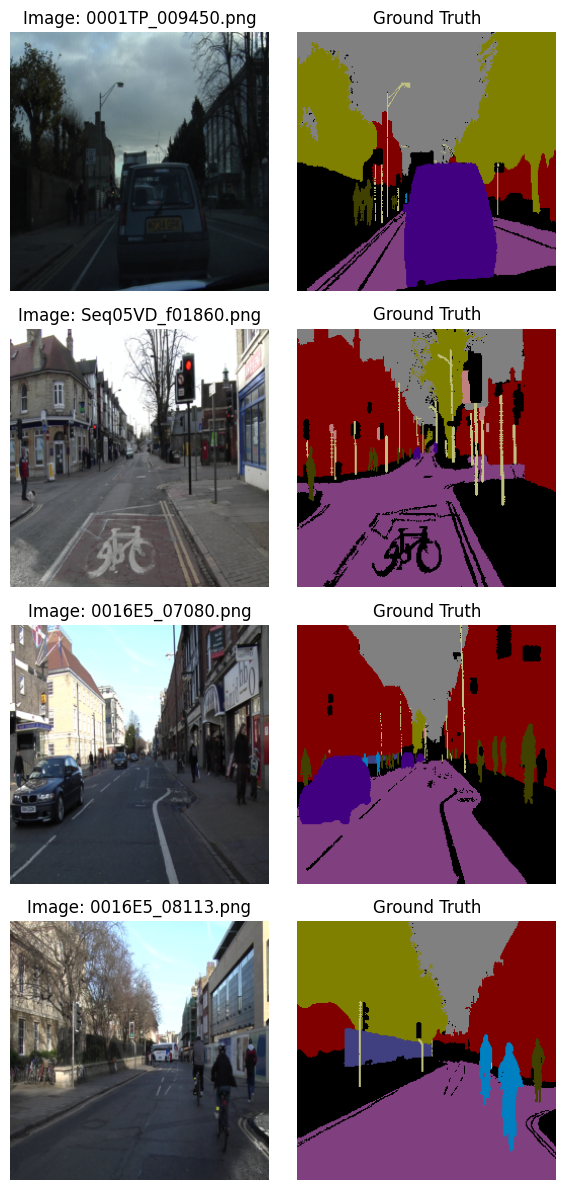

In [ ]:
# === Visualize a few (image, mask) pairs ===

def show_pairs(ds, n=4):
    n = min(n, len(ds))
    idxs = random.sample(range(len(ds)), k=n) if len(ds) >= n else list(range(len(ds)))
    fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(6, 3*n))
    if n == 1:
        axes = np.array([axes])
    for i, idx in enumerate(idxs):
        img_t, mask_t, name = ds[idx]
        img = img_t.permute(1,2,0).numpy()
        img = (img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406]))  # de-normalize
        img = np.clip(img, 0, 1)
        mask = mask_t.cpu().numpy()
        gt_im = colorize_index_mask(np.where(mask==IGNORE_INDEX, IGNORE_INDEX, mask))

        # Try different approaches to visualize the mask
        axes[i,0].imshow(img); axes[i,0].set_title(f"Image: {name}"); axes[i,0].axis('off')

        # Option 1: Direct visualization
        axes[i,1].imshow(gt_im); axes[i,1].set_title("Ground Truth"); axes[i,1].axis('off')


    plt.tight_layout(); plt.show()

if len(train_ds) > 0:
    show_pairs(train_ds, n=4)  # Start with just 1 sample for debugging
else:
    print("Dataset empty. If auto-download failed, please follow Option B and rerun.")


## 3) Model: U‑Net with C‑channel head

Exactly like P22, except the final `Conv2d` outputs **NUM_CLASSES=11**.  



In [ ]:

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_ch, out_ch))
    def forward(self, x): return self.net(x)

class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch//2, 2, stride=2)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x1, x2):
        x1 = self.up(x1)
        # pad/crop to match skip spatial dims
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX//2, diffX - diffX//2, diffY//2, diffY - diffY//2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.inc = DoubleConv(3, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024)
        self.up1 = Up(1024, 512)
        self.up2 = Up(512, 256)
        self.up3 = Up(256, 128)
        self.up4 = Up(128, 64)
        self.outc = nn.Conv2d(64, n_classes, 1)
    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        return self.outc(x)

model = UNet(NUM_CLASSES).to(DEVICE)
print(f"Model params: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")


Model params: 31.04M



## 4) Loss & Optimizer

- Use `nn.CrossEntropyLoss(ignore_index=11)` so void pixels don’t contribute.  
- Optimizer: **Adam** (LR = 1e-3) is a good default for class.


In [ ]:

criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)



## 5) Metrics: Confusion Matrix → IoU, mIoU, Pixel Accuracy

For each class c:
- IoU(c) = TP / (TP + FP + FN)  
- mIoU = mean over classes (ignoring NaNs if a class is absent)


In [ ]:

@torch.no_grad()
def fast_confusion_matrix(pred, target, num_classes, ignore_index=IGNORE_INDEX):
    # pred/target: BxHxW class IDs
    cm_total = np.zeros((num_classes, num_classes), dtype=np.int64)
    if pred.ndim == 3:  # B,H,W
        for p, t in zip(pred, target):
            mask = t != ignore_index
            p = p[mask]; t = t[mask]
            inds = num_classes * t.to(torch.int64) + p
            cm = torch.bincount(inds, minlength=num_classes**2).reshape(num_classes, num_classes).cpu().numpy()
            cm_total += cm
    else:
        raise ValueError("Expected pred to be BxHxW")
    return cm_total

def iou_from_cm(cm):
    tp = np.diag(cm)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    denom = tp + fp + fn
    iou = np.where(denom>0, tp/denom, np.nan)
    miou = np.nanmean(iou)
    return iou, miou

def pixel_acc_from_cm(cm):
    return np.diag(cm).sum() / max(1, cm.sum())

@torch.no_grad()
def evaluate(model, loader, num_classes=NUM_CLASSES):
    model.eval()
    cm_total = np.zeros((num_classes, num_classes), dtype=np.int64)
    for imgs, masks, _ in loader:
        imgs = imgs.to(DEVICE); masks = masks.to(DEVICE)
        logits = model(imgs)
        preds = logits.argmax(1)
        cm_total += fast_confusion_matrix(preds, masks, num_classes)
    iou, miou = iou_from_cm(cm_total)
    pixacc = pixel_acc_from_cm(cm_total)
    return cm_total, iou, miou, pixacc



## 6) Training Loop



In [ ]:

history = {'train_loss': [], 'val_miou': [], 'val_pixacc': []}

for epoch in range(1, EPOCHS+1):
    model.train()
    running = 0.0
    t0 = time.time()
    for b, (imgs, masks, _) in enumerate(train_loader, 1):
        imgs = imgs.to(DEVICE); masks = masks.to(DEVICE)
        logits = model(imgs)                      # [B, C, H, W]
        loss = criterion(logits, masks)           # CrossEntropy expects raw logits + Long targets

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running += loss.item()
        if b % PRINT_EVERY == 0:
            print(f"Epoch {epoch:02d} [{b:04d}/{len(train_loader)}] loss={running/b:.4f}")

    avg_loss = running / max(1, len(train_loader))
    cm, iou, miou, pixacc = evaluate(model, val_loader, NUM_CLASSES)
    history['train_loss'].append(avg_loss)
    history['val_miou'].append(miou)
    history['val_pixacc'].append(pixacc)

    print(f"Epoch {epoch:02d} | loss={avg_loss:.4f} | mIoU={miou:.3f} | pixelAcc={pixacc:.3f} | time={time.time()-t0:.1f}s")


Epoch 01 [0050/62] loss=0.3702


C:\Users\dell\AppData\Local\Temp\ipykernel_15300\1997952056.py:21: RuntimeWarning: invalid value encountered in divide
  iou = np.where(denom>0, tp/denom, np.nan)


Epoch 01 | loss=0.3652 | mIoU=0.426 | pixelAcc=0.899 | time=28.6s
Epoch 02 [0050/62] loss=0.3696
Epoch 02 | loss=0.3665 | mIoU=0.416 | pixelAcc=0.890 | time=28.3s
Epoch 03 [0050/62] loss=0.3187
Epoch 03 | loss=0.3156 | mIoU=0.400 | pixelAcc=0.869 | time=28.5s
Epoch 04 [0050/62] loss=0.2930
Epoch 04 | loss=0.2988 | mIoU=0.424 | pixelAcc=0.893 | time=28.6s
Epoch 05 [0050/62] loss=0.2981
Epoch 05 | loss=0.2954 | mIoU=0.420 | pixelAcc=0.868 | time=28.6s
Epoch 06 [0050/62] loss=0.2787
Epoch 06 | loss=0.2825 | mIoU=0.395 | pixelAcc=0.855 | time=28.7s
Epoch 07 [0050/62] loss=0.3118
Epoch 07 | loss=0.3078 | mIoU=0.467 | pixelAcc=0.915 | time=28.7s
Epoch 08 [0050/62] loss=0.2825
Epoch 08 | loss=0.2799 | mIoU=0.454 | pixelAcc=0.911 | time=28.9s
Epoch 09 [0050/62] loss=0.2576
Epoch 09 | loss=0.2540 | mIoU=0.494 | pixelAcc=0.921 | time=28.8s
Epoch 10 [0050/62] loss=0.2505
Epoch 10 | loss=0.2527 | mIoU=0.501 | pixelAcc=0.904 | time=28.8s
Epoch 11 [0050/62] loss=0.2623
Epoch 11 | loss=0.2606 | mIoU=


## 7) Curves


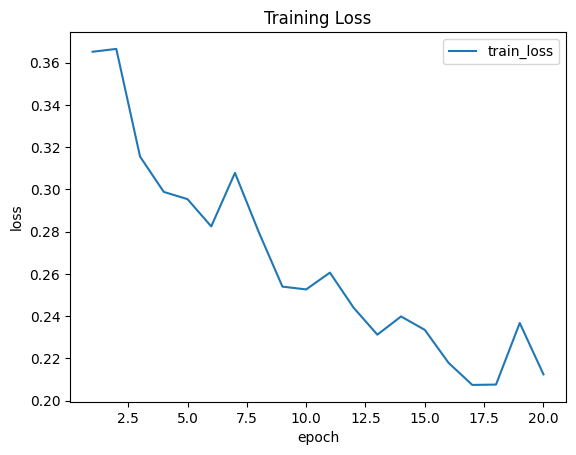

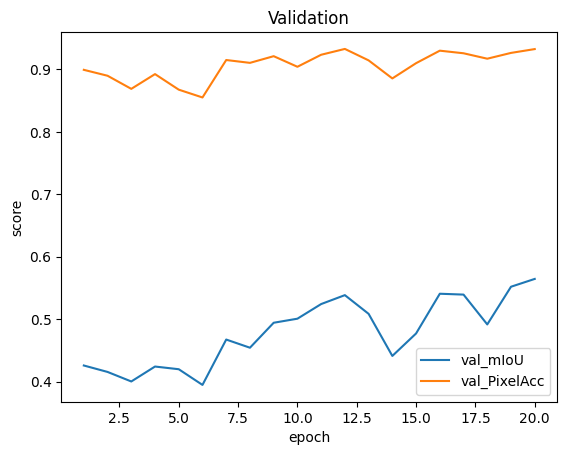

In [ ]:

xs = range(1, len(history['train_loss'])+1)

plt.figure(); plt.plot(xs, history['train_loss'], label='train_loss')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.title('Training Loss'); plt.legend(); plt.show()

plt.figure(); plt.plot(xs, history['val_miou'], label='val_mIoU')
plt.plot(xs, history['val_pixacc'], label='val_PixelAcc')
plt.xlabel('epoch'); plt.ylabel('score'); plt.title('Validation'); plt.legend(); plt.show()



## 8) Qualitative Results (GT vs. Pred)


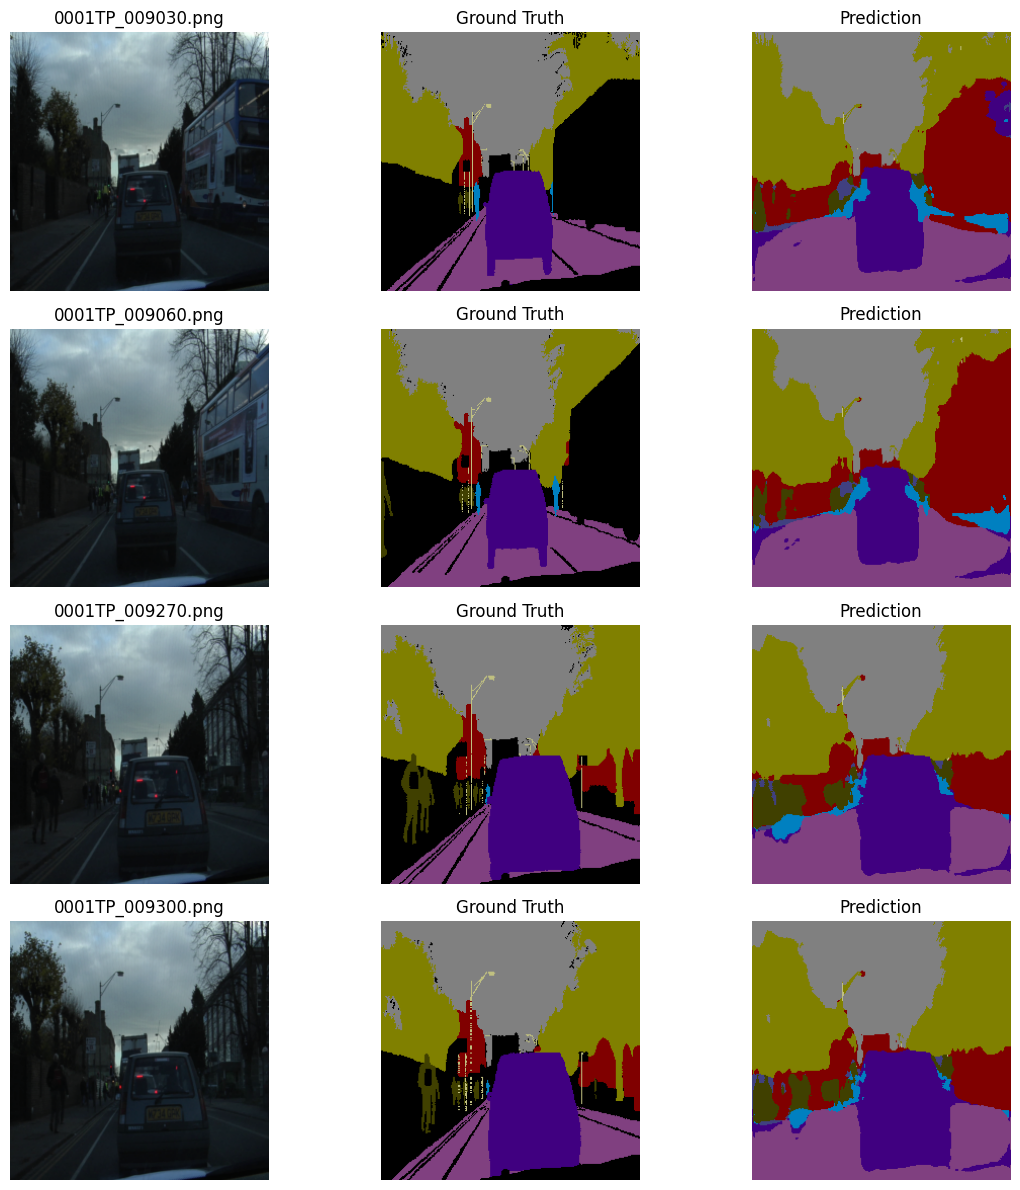

In [ ]:

@torch.no_grad()
def visualize_batch(model, loader, num_images=4):
    model.eval()
    imgs, masks, names = next(iter(loader))
    imgs = imgs.to(DEVICE); masks = masks.to(DEVICE)
    logits = model(imgs); preds = logits.argmax(1)

    # denormalize for display
    mean = np.array([0.485,0.456,0.406]); std = np.array([0.229,0.224,0.225])
    imgs_np = imgs.cpu().permute(0,2,3,1).numpy()
    imgs_np = np.clip((imgs_np*std + mean)*255, 0, 255).astype(np.uint8)

    n = min(num_images, imgs.size(0))
    plt.figure(figsize=(12, 3*n))
    for i in range(n):
        gt = masks[i].cpu().numpy()
        pr = preds[i].cpu().numpy()
        gt_im = colorize_index_mask(np.where(gt==IGNORE_INDEX, IGNORE_INDEX, gt))
        pr_im = colorize_index_mask(pr)

        plt.subplot(n,3,3*i+1); plt.imshow(imgs_np[i]); plt.axis('off'); plt.title(names[i])
        plt.subplot(n,3,3*i+2); plt.imshow(gt_im);       plt.axis('off'); plt.title('Ground Truth')
        plt.subplot(n,3,3*i+3); plt.imshow(pr_im);       plt.axis('off'); plt.title('Prediction')
    plt.tight_layout(); plt.show()

visualize_batch(model, val_loader, num_images=4)



## 9) Per-class IoU Table


In [ ]:

import pandas as pd
cm, iou, miou, pixacc = evaluate(model, val_loader, NUM_CLASSES)
print(f"mIoU={miou:.3f}  pixelAcc={pixacc:.3f}")
pd.DataFrame({'class': CAMVID_CLASSES, 'IoU': iou[:len(CAMVID_CLASSES)]})


mIoU=0.565  pixelAcc=0.933


C:\Users\dell\AppData\Local\Temp\ipykernel_15300\1997952056.py:21: RuntimeWarning: invalid value encountered in divide
  iou = np.where(denom>0, tp/denom, np.nan)


,class,IoU
0,Sky,0.918934
1,Building,0.875852
2,Pole,0.102948
3,Road,0.979764
4,Pavement,NaN
5,Tree,0.776955
6,SignSymbol,0.015787
7,Fence,0.467105
8,Car,0.807894
9,Pedestrian,0.285525



## 10) Common Debugging

- **Wrong mask interpolation:** Always use **NEAREST** for masks; bilinear will corrupt class IDs.  
- **Forgetting `ignore_index`:** Unlabeled pixels must be ignored in the loss and metrics.  
- **Applying softmax in the model:** Don’t. Pass raw logits to `CrossEntropyLoss`.  
- **Class imbalance:** Some classes (e.g., Pedestrian) are rare. Consider **class weights**.



## 11) Exercises (Hands-On)
1) **Resolution ablation:** Train with 192, 224, 256; report mIoU trends.  
2) **Augmentations:** Add `ColorJitter`, `RandomResizedCrop`, stronger flips.  
3) **Class-balanced loss:** Estimate class frequencies over the train set and pass `weight=...` to `CrossEntropyLoss`.  
4) **Encoder swap:** Replace down blocks with a pretrained ResNet-34 encoder (freeze vs. fine-tune).  
5) **CRF post-processing (bonus):** Apply DenseCRF over softmax probabilities; measure mIoU gain.



## 12) Summary: Connect back to Practical 22
- You upgraded U-Net from **binary** to **multi-class** by changing the **head** and **loss**.  
- You learned to convert **color masks** to **class indices** and to handle **ignore** labels.  
- You implemented and interpreted **per-class IoU** and **mIoU**, key metrics in segmentation papers.


### What’s next?
- Next up practical: **U-Net Family**, U-Net++, Residual U-Net, and Attention U-Net. You’ll compare accuracy vs. complexity and discuss trade-offs.

---

📝 This practical was designed to give you hands-on with **multi-class image segmentation** using **U-Net**, covering color-to-class mask conversion, softmax with CrossEntropyLoss, and evaluation with IoU and mIoU.